In [25]:
import pandas as pd

In [47]:
kaggle = pd.read_csv('data/final_kaggle_dataset.csv',escapechar='\\')

In [48]:
kaggle

,song,artists,lyrics,genres
0,Illusions,['Cypress Hill'],Some people tell me that I need help Some peop...,"['chicano rap', 'gangster rap', 'hardcore hip ..."
1,Touching the Ground,['Brandi Carlile'],I swear when we touched I saw heaven in your ...,"['folk', 'indie pop', 'lilith', 'neo mellow', ..."
2,Nothing Is Stopping You,['Big Sean'],Nothing is stopping you Stopping you Stopping ...,"['detroit hip hop', 'hip hop', 'pop', 'pop rap..."
3,I Shall Believe,['Sheryl Crow'],Come to me now And lay your hands over me Even...,"['lilith', 'mellow gold', 'neo mellow', 'new w..."
4,Why Trust You,['Alice Cooper'],You come on strong with a great big smile But ...,"['album rock', 'blues rock', 'classic rock', '..."
...,...,...,...,...
5808,New Morning,['My Morning Jacket'],Wakin' up feelin' good and limber When the tel...,"['alternative rock', 'blues rock', 'indie folk..."
5809,Bel Air,['Lana Del Rey'],Gargoyles standing at the front of your gate T...,"['art pop', 'pop']"
5810,Harambe,['Young Thug'],Mafia Billboard Hitmakers Yeah AP gang bitch...,"['atl hip hop', 'gangster rap', 'hip hop', 'me..."
5811,Fun,['Selena Gomez'],This is just what the doctor ordered Put a gol...,"['dance pop', 'pop', 'post-teen pop']"


In [49]:
api = pd.read_csv('data/additional_songs.csv',escapechar='\\')

In [50]:
api

,song,artists,genres,lyrics
0,Ollaanko tämä kesä näin?,['Olavi Uusivirta'],rock,[Säkeistö 1]\nKesä on täällä taas\nIstutaan hi...
1,Levoton Tuhkimo,['Dingo'],rock,[Säkeistö 1]\nJuot ja katselet vieraisiin pöyt...
2,Matkustaja,['Egotrippi'],rock,"[Säkeistö 1]\nYöllä linja-autossa, yksi väsyny..."
3,In the End,['Linkin Park'],rock,[Intro: Chester Bennington]\nIt starts with on...
4,Todella kaunis,['Zen Cafe'],rock,[Säkeistö 1]\nMe kohtaisimme aina silloin kun ...
...,...,...,...,...
768,Headstone Lane,['UDM'],trance,Hands up now {*repeat 14X*}\n\n[Hook: Nelly]\n...
769,Wish You Were Here,['JES'],trance,"So, so you think you can tell Heaven from Hell..."
770,See the Sun,['ASP Project'],trance,See the sun as it sets behind the light\nAnd I...
771,Risk It All,['Altitude'],trance,They said\nSay a prayer for the sinners\nSay a...


In [51]:
api.isna().sum()

song       0
artists    0
genres     0
lyrics     0
dtype: int64

In [52]:
api[api['lyrics']=="THIS SONG DON'T HAVE A LIRICS"]

,song,artists,genres,lyrics
772,No Hands But Yours,['Mandala'],trance,THIS SONG DON'T HAVE A LIRICS


In [53]:
api = api[api['lyrics']!="THIS SONG DON'T HAVE A LIRICS"]

In [54]:
from langdetect import detect

In [55]:
def detect_lang(x):
    try:
        return detect(str(x))
    except:
        return 'unknown'

In [56]:
languages = api['lyrics'].apply(detect_lang)

<Axes: xlabel='lyrics'>

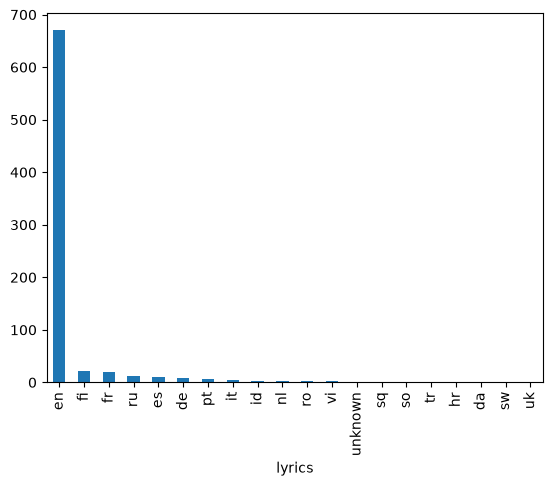

In [57]:
languages.value_counts().plot(kind='bar')

In [58]:
api.shape

(772, 4)

In [59]:
api = api[languages=='en']

In [60]:
api.shape

(670, 4)

In [61]:
api

,song,artists,genres,lyrics
3,In the End,['Linkin Park'],rock,[Intro: Chester Bennington]\nIt starts with on...
8,Enter Sandman - Remastered 2021,['Metallica'],rock,BTS - Butter\nMaroon 5 - Memories\nImagine Dra...
9,Numb,['Linkin Park'],rock,[Verse 1: Chester Bennington]\nI'm tired of be...
13,Forgot about Father (Say Miss),['Natalac'],rap,"The mother was small and thin, with shoulders,..."
14,Among Us Rap,['Zigred'],rap,"[Intro: Boyz II Men & Krizz Kaliko]\n1, 2, 3, ..."
...,...,...,...,...
767,BASH!!,"['Marco V', 'Jochen Miller']",dutch trance,God broke the mould\nWhen he made this one I k...
768,Headstone Lane,['UDM'],trance,Hands up now {*repeat 14X*}\n\n[Hook: Nelly]\n...
769,Wish You Were Here,['JES'],trance,"So, so you think you can tell Heaven from Hell..."
770,See the Sun,['ASP Project'],trance,See the sun as it sets behind the light\nAnd I...


# Объединение двух датасетов

In [41]:
kaggle_exploded = kaggle.explode('artists')
kaggle_exploded

,song,artists,lyrics,genres
0,Illusions,['Cypress Hill'],Some people tell me that I need help Some peop...,"['chicano rap', 'gangster rap', 'hardcore hip ..."
1,Touching the Ground,['Brandi Carlile'],I swear when we touched I saw heaven in your ...,"['folk', 'indie pop', 'lilith', 'neo mellow', ..."
2,Nothing Is Stopping You,['Big Sean'],Nothing is stopping you Stopping you Stopping ...,"['detroit hip hop', 'hip hop', 'pop', 'pop rap..."
3,I Shall Believe,['Sheryl Crow'],Come to me now And lay your hands over me Even...,"['lilith', 'mellow gold', 'neo mellow', 'new w..."
4,Why Trust You,['Alice Cooper'],You come on strong with a great big smile But ...,"['album rock', 'blues rock', 'classic rock', '..."
...,...,...,...,...
5808,New Morning,['My Morning Jacket'],Wakin' up feelin' good and limber When the tel...,"['alternative rock', 'blues rock', 'indie folk..."
5809,Bel Air,['Lana Del Rey'],Gargoyles standing at the front of your gate T...,"['art pop', 'pop']"
5810,Harambe,['Young Thug'],Mafia Billboard Hitmakers Yeah AP gang bitch...,"['atl hip hop', 'gangster rap', 'hip hop', 'me..."
5811,Fun,['Selena Gomez'],This is just what the doctor ordered Put a gol...,"['dance pop', 'pop', 'post-teen pop']"
